# Getting started with MemsArrayH5 objects

The `MemsArrayH5` class allows getting signals from MemsArray saved in a H5 file with data formated as MuH5 format

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from megamicros.log import log
from megamicros.core.h5 import MemsArrayH5

log.setLevel( "INFO" )

# Choose a file where some H5 files are stored
DIRECTORY = '/Users/brunogas/Data/muh5/'

# Choose a H5 file
#FILENAME = DIRECTORY + 'mu5h-20220630-064820.h5'
FILENAME = DIRECTORY + 'mu5h-20220124-002506.h5'
#FILENAME = DIRECTORY + 'mu5h-20220720-160341.h5'

## Starting with simple signals

One has only to specify the file or directory name where to find H5 files.

The ``MemsArrayH5`` open the input H5 file or the first H5 file of the directory list and populates the antenna parameters with metadata read from the file. An exception is raised if file or directory are not found.

In [13]:
# Define the antenna
antenna = MemsArrayH5( 
    filename=FILENAME
)

2023-10-09 13:38:14,547 [INFO]:  .Install MemsArray settings
2023-10-09 13:38:14,548 [INFO]:  .Created a new antenna
2023-10-09 13:38:14,555 [INFO]:  .Found /Users/brunogas/Data/muh5/mu5h-20220124-002506.h5 MuH5 file
2023-10-09 13:38:14,560 [INFO]:  .Set 32 available MEMs numbered from 0 to 31
2023-10-09 13:38:14,562 [INFO]:  .No analogic channels available


meta =  {'analogs': array([], dtype=float64), 'analogs_number': 0, 'channels_number': 32, 'comment': '', 'compression': False, 'counter': True, 'counter_skip': True, 'dataset_duration': 1, 'dataset_length': 10000, 'dataset_number': 900, 'datatype': 'int32', 'date': '2022-06-24 00:25:06.822535', 'duration': 900, 'mems': array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31]), 'mems_number': 32, 'sampling_frequency': 10000.0, 'timestamp': 1656023106.822535}


You can get now some Meta informations regarding the file

In [ ]:
print( f"Sampling frequency: {antenna.sampling_frequency}Hz" )
print( f"Available MEMs number: {antenna.available_mems_number}" )
print( f"Whether counter is available or not: {antenna.counter}" )

## Getting and plotting some MEMs signals

You can select some MEMs you would like to plot and get signals on a given range time (10 seconds in this example)

In [3]:
# Run antenna
antenna.run(
    mems = [5, 6],
    duration=10,
    counter_skip = True,
    datatype='int32'
)

# Init a np.ndarray
signals = np.ndarray( (0, antenna.channels_number ) )

# Get signals
for data in antenna:
    signals = np.concatenate( ( signals, data ), axis=0 )

# waiting for the end of the running thread is mandatory
antenna.wait()
print( f"exit from loop. Signal shape is: {np.shape( signals )}" )

2023-10-09 13:33:26,090 [INFO]:  .Starting run execution
2023-10-09 13:33:26,094 [INFO]:  .Install MemsArray settings
2023-10-09 13:33:26,096 [INFO]:  .2 MEMs were activated among 0 to 31 available MEMs
2023-10-09 13:33:26,097 [INFO]:  .Set datatype to int32 
2023-10-09 13:33:26,098 [INFO]:  .Install MemsArray settings
2023-10-09 13:33:26,099 [INFO]:  .2 MEMs were activated among 0 to 31 available MEMs
2023-10-09 13:33:26,100 [INFO]:  .Set datatype to int32 
2023-10-09 13:33:26,102 [INFO]:  .Pre-execution checks for MemsArray object
2023-10-09 13:33:26,104 [INFO]:  .Pre-execution checks for MemsArrayH5 object
2023-10-09 13:33:26,106 [INFO]:  .Perform a 10s run loop
2023-10-09 13:33:26,109 [INFO]:  .Frame length: 256 samples (chunk size: 2048 Bytes)
2023-10-09 13:33:26,110 [INFO]:  .Sampling frequency: 10000.0 Hz
2023-10-09 13:33:26,111 [INFO]:  .Active MEMs: [5, 6]
2023-10-09 13:33:26,112 [INFO]:  .Active analogic channels: []
2023-10-09 13:33:26,113 [INFO]:  .Whether counter is active

exit from loop. Signal shape is: (148224, 2)


Here is the plotting program

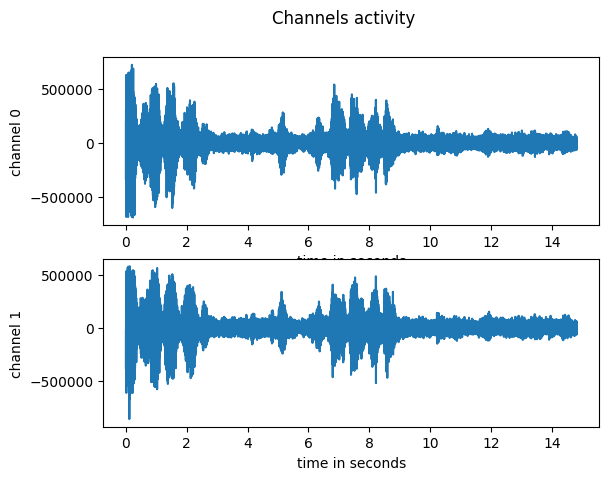

In [4]:
# plot signals
time = np.array( range( np.size(signals,0) ) )/antenna.sampling_frequency
fig, axs = plt.subplots( antenna.channels_number )
fig.suptitle('Channels activity')	
for s in range( antenna.channels_number ):
    axs[s].plot( time, signals[:,s] )
    axs[s].set( xlabel='time in seconds', ylabel='channel %d' % s )

plt.show()

## Saving signals as wave file

In [15]:
import wave

WAV_FILENAME = 'titi.wav'

# 2 seconds run, getting signals from MEMs 1 and 2
antenna.run(
    mems = [5, 6],
    duration=5,
    counter_skip = True,
    datatype='int32'
)

with  wave.open( WAV_FILENAME, mode='wb' ) as wavfile:
    wavfile.setnchannels(2)
    wavfile.setsampwidth(2)
    wavfile.setframerate( antenna.sampling_frequency )

    # Get signals
    for data in antenna:
        signal = data >> 4
        wavfile.writeframesraw( np.int16( np.reshape( signal, np.size( signal ), order='C' ) ) )

# waiting for the end of the running thread is mandatory
antenna.wait()

2023-10-09 13:39:44,569 [INFO]:  .Starting run execution
2023-10-09 13:39:44,571 [INFO]:  .Install MemsArray settings
2023-10-09 13:39:44,574 [INFO]:  .2 MEMs were activated among 0 to 31 available MEMs
2023-10-09 13:39:44,576 [INFO]:  .Set datatype to int32 
2023-10-09 13:39:44,577 [INFO]:  .Install MemsArray settings
2023-10-09 13:39:44,579 [INFO]:  .2 MEMs were activated among 0 to 31 available MEMs
2023-10-09 13:39:44,580 [INFO]:  .Set datatype to int32 
2023-10-09 13:39:44,581 [INFO]:  .Pre-execution checks for MemsArray object
2023-10-09 13:39:44,581 [INFO]:  .Pre-execution checks for MemsArrayH5 object
2023-10-09 13:39:44,582 [WARNING]: in megamicros.log (h5.py:366): `counter_skip` is set to True but `counter` is not available
2023-10-09 13:39:44,583 [INFO]:  .Perform a 5s run loop
2023-10-09 13:39:44,584 [INFO]:  .Frame length: 512 samples (chunk size: 4096 Bytes)
2023-10-09 13:39:44,585 [INFO]:  .Sampling frequency: 10000.0 Hz
2023-10-09 13:39:44,586 [INFO]:  .Active MEMs: [5,

## Hearing signal with *pyaudio* library

In [16]:
import pyaudio

FRAME_LENGTH = 512

# Instantiate PyAudio and initialize PortAudio system resources (1)
p = pyaudio.PyAudio()

# Open stream
stream = p.open(
    format = pyaudio.paFloat32,
    channels = 2,
    rate = int( antenna.sampling_frequency ),
    output=True,
    frames_per_buffer=FRAME_LENGTH,
)

# Start running the remote Megamicros system
antenna.run( 
    mems=[1, 2],
    duration=10,
    frame_length=FRAME_LENGTH,
    counter_skip = True,
    datatype='int32'
)

# Get signals
transfers_counter = 0
for data in antenna:
    signal = data >> 4

    # convert into float and normalize with MEMs sensibility
    data = ( data.astype( np.float32 ) * antenna.sensibility )

    # write into audio stream
    stream.write( data.tobytes( order='C'), num_frames=FRAME_LENGTH )
    transfers_counter += 1

# Close stream and release PortAudio system resources (5)
stream.close()            
p.terminate()

antenna.wait()

2023-10-09 13:40:53,348 [INFO]:  .Starting run execution
2023-10-09 13:40:53,349 [INFO]:  .Install MemsArray settings
2023-10-09 13:40:53,350 [INFO]:  .2 MEMs were activated among 0 to 31 available MEMs
2023-10-09 13:40:53,355 [INFO]:  .Set datatype to int32 
2023-10-09 13:40:53,356 [INFO]:  .Install MemsArray settings
2023-10-09 13:40:53,357 [INFO]:  .2 MEMs were activated among 0 to 31 available MEMs
2023-10-09 13:40:53,358 [INFO]:  .Set datatype to int32 
2023-10-09 13:40:53,360 [INFO]:  .Pre-execution checks for MemsArray object
2023-10-09 13:40:53,361 [INFO]:  .Pre-execution checks for MemsArrayH5 object
2023-10-09 13:40:53,365 [WARNING]: in megamicros.log (h5.py:366): `counter_skip` is set to True but `counter` is not available
2023-10-09 13:40:53,366 [INFO]:  .Perform a 10s run loop
2023-10-09 13:40:53,367 [INFO]:  .Frame length: 512 samples (chunk size: 4096 Bytes)
2023-10-09 13:40:53,368 [INFO]:  .Sampling frequency: 10000.0 Hz
2023-10-09 13:40:53,369 [INFO]:  .Active MEMs: [1